# 🧠 StressTest — Cognitive Load Manager
## GRPO Training on Google Colab T4 GPU

**Meta PyTorch OpenEnv Hackathon**

This notebook:
1. Installs all dependencies
2. Uploads your CLM codebase
3. Starts the FastAPI backend server in background
4. Runs GRPO training for 1000 steps
5. Saves detailed reward metrics to `reward_curve.json`
6. Plots the learning curve

### ⚙️ Runtime Setup
Before running: **Runtime → Change runtime type → T4 GPU**

## Cell 1 — Check GPU

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '❌ No GPU found. Change runtime to T4 GPU.')

Sat Apr 25 19:58:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 — Install Dependencies

In [2]:
%%capture
# Core training stack
!pip install trl>=0.12.0 transformers>=4.46.0 datasets accelerate peft

# Unsloth for 2x faster training on T4
!pip install unsloth

# Backend dependencies
!pip install fastapi uvicorn pydantic requests

# Plotting
!pip install matplotlib

print('✅ All dependencies installed')

## Cell 3 — Upload Your Codebase
Upload the `cognitive-load-manager-main.zip` file when prompted.

In [3]:
from google.colab import files
import zipfile, os

print('📁 Upload your cognitive-load-manager-main.zip file')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')

# Find the extracted folder
extracted = [d for d in os.listdir('/content/')
             if 'cognitive' in d.lower() and os.path.isdir(f'/content/{d}')]
PROJECT_DIR = f'/content/{extracted[0]}' if extracted else '/content/cognitive-load-manager-main'
print(f'✅ Extracted to: {PROJECT_DIR}')
os.listdir(PROJECT_DIR)

📁 Upload your cognitive-load-manager-main.zip file


Saving cognitive-load-manager-main.zip to cognitive-load-manager-main.zip
✅ Extracted to: /content/cognitive-load-manager-main


['training_loop.py',
 'pyproject.toml',
 'server',
 'requirements.txt',
 'Dockerfile',
 'inference.py',
 'README.md',
 'package.json',
 'backend',
 'grader',
 'models.py',
 'openai_inspect.py',
 'frontend',
 'tests',
 '.gitignore',
 'validate_submission.py',
 'openenv.yaml',
 'package-lock.json',
 'uv.lock',
 '.github']

## Cell 4 — Start the CLM Backend Server in Background

In [4]:
import requests

CLM_SERVER = "https://anonymousdevil-cognitive-load-manager.hf.space"

# Test the live HF Space is reachable
print(f"Testing connection to: {CLM_SERVER}")

try:
    r = requests.get(f"{CLM_SERVER}/health", timeout=15)
    print(f"✅ Server is live: {r.json()}")
except Exception as e:
    print(f"❌ Cannot reach HF Space: {e}")
    print("Check: https://huggingface.co/spaces/anonymousDevil/cognitive-load-manager")

# Test reset
resp = requests.post(f"{CLM_SERVER}/reset", json={"task_id": "medium"}, timeout=15)
print(f"\n🔄 Reset test: status={resp.status_code}")
data = resp.json()
print(f"   session_id: {data['session_id'][:16]}...")
print(f"   tasks: {len(data['observation']['tasks'])}")
print(f"   workers: {len(data['observation']['visible_state']['workers'])}")

Testing connection to: https://anonymousdevil-cognitive-load-manager.hf.space
✅ Server is live: {'status': 'healthy', 'sessions': 6, 'training': 'completed'}

🔄 Reset test: status=200
   session_id: 8bfbb78f-7fb9-43...
   tasks: 5
   workers: 3


## Cell 5 — Verify Reward Function Works

In [5]:
import requests, json, re

CLM_SERVER = 'https://anonymousdevil-cognitive-load-manager.hf.space'

def parse_action(text):
    try:
        m = re.search(r'\{[^{}]*\}', text)
        if m:
            p = json.loads(m.group(0))
            if 'type' in p:
                return p
    except:
        pass
    return {'type': 'delay'}

def get_reward_for_action(action_json_str):
    """Play one step in the environment and return the real reward."""
    reset_r = requests.post(f'{CLM_SERVER}/reset', json={'task_id': 'medium'}).json()
    obs = reset_r.get('observation', {})
    tasks = obs.get('tasks', [])

    action = parse_action(action_json_str)
    if action.get('type') in ('work', 'focus') and not action.get('task_id'):
        if tasks:
            action['task_id'] = tasks[0]['id']

    step_r = requests.post(f'{CLM_SERVER}/step', json={'action': action}).json()
    return step_r.get('reward', 0.0)

# Test different actions
print('🧪 Testing reward function with different actions:')
print('-' * 60)
test_actions = [
    ('{"type": "work", "task_id": "m1"}',  'Work on task'),
    ('{"type": "focus", "task_id": "m1"}', 'Focus on task'),
    ('{"type": "break"}',                  'Take a break'),
    ('{"type": "delay"}',                  'Delay (do nothing)'),
    ('invalid garbage text',               'Invalid output (penalty)'),
]
for action_str, label in test_actions:
    r = get_reward_for_action(action_str)
    bar = '█' * int(abs(r) * 20)
    sign = '+' if r >= 0 else '-'
    print(f'  {label:25s} → reward: {sign}{abs(r):.4f}  {bar}')

print('\n✅ Reward function is working correctly!')

🧪 Testing reward function with different actions:
------------------------------------------------------------
  Work on task              → reward: +0.1020  ██
  Focus on task             → reward: +0.2490  ████
  Take a break              → reward: +0.0300  
  Delay (do nothing)        → reward: +0.0100  
  Invalid output (penalty)  → reward: +0.0100  

✅ Reward function is working correctly!


## Cell 6 — How Reward Is Calculated (Full Explanation)

This cell documents **exactly** how each reward number is computed.

In [6]:
REWARD_BREAKDOWN = """
╔══════════════════════════════════════════════════════════════════════╗
║           HOW REWARD IS CALCULATED IN CLM ENVIRONMENT               ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DENSE STEP REWARDS (every action):                                  ║
║  ─────────────────────────────────                                   ║
║  Task progress:        +0.10 × progress_delta × priority_weight     ║
║    (priority weights: critical=2.0, high=1.5, normal=1.0, low=0.7)  ║
║                                                                      ║
║  Milestone bonuses:                                                  ║
║    25% progress hit:   +0.04 × priority_weight                      ║
║    50% progress hit:   +0.07 × priority_weight                      ║
║    75% progress hit:   +0.09 × priority_weight                      ║
║    100% (task done):   +0.18 × priority_weight                      ║
║                                                                      ║
║  Break action:         +0.03 (energy recovery reward)               ║
║                                                                      ║
║  PENALTIES (every step):                                             ║
║  ─────────────────────────────────                                   ║
║  Context switch (similar tasks back-to-back): -0.15 (HIGH penalty)  ║
║  Context switch (different task types):       -0.05 (LOW penalty)   ║
║  Working on blocked task:                     -0.15                  ║
║  Delay action (doing nothing):                -0.07                  ║
║  Deadline pushed to tomorrow:                 -0.05 (moderate)      ║
║  Low priority task not allocated:             -0.07 (not extreme)   ║
║  BURNOUT (energy hits zero):                  -1.00 (episode killer)║
║                                                                      ║
║  EPISODE END REWARDS:                                                ║
║  ─────────────────────────────────                                   ║
║  All tasks done on time:                      +1.00                  ║
║  All tasks done (some late):                  +0.50                  ║
║                                                                      ║
║  FINAL CLAMP: reward = max(-1.0, min(1.0, reward))                  ║
║                                                                      ║
║  FINAL GRADER SCORE (0.01 to 0.99):                                  ║
║  weighted_completion  × 0.60                                         ║
║  + deadline_adherence × 0.22                                         ║
║  + energy_efficiency  × 0.10                                         ║
║  + dependency_bonus   × 0.05                                         ║
║  + interruption_bonus × 0.03                                         ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(REWARD_BREAKDOWN)


╔══════════════════════════════════════════════════════════════════════╗
║           HOW REWARD IS CALCULATED IN CLM ENVIRONMENT               ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  DENSE STEP REWARDS (every action):                                  ║
║  ─────────────────────────────────                                   ║
║  Task progress:        +0.10 × progress_delta × priority_weight     ║
║    (priority weights: critical=2.0, high=1.5, normal=1.0, low=0.7)  ║
║                                                                      ║
║  Milestone bonuses:                                                  ║
║    25% progress hit:   +0.04 × priority_weight                      ║
║    50% progress hit:   +0.07 × priority_weight                      ║
║    75% progress hit:   +0.09 × priority_weight                      ║
║    100% (task done):   +0.18 × priority_weight        

## Cell 7 — Load Model (Unsloth for 2x Speed on T4)

In [7]:
import torch

print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB'
      if torch.cuda.is_available() else '')

# Try Unsloth first (2x faster), fall back to standard transformers
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

try:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=1024,
        load_in_4bit=True,   # 4-bit quantisation — fits T4 16GB VRAM
        dtype=None,
    )
    # Add LoRA adapters (only trains ~1% of params — much faster)
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=['q_proj','k_proj','v_proj','o_proj'],
        lora_alpha=16,
        lora_dropout=0,
        bias='none',
    )
    USE_UNSLOTH = True
    print('✅ Unsloth loaded — 2x faster training active')
except Exception as e:
    print(f'Unsloth not available ({e}), using standard transformers')
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map='auto',
    )
    USE_UNSLOTH = False
    print('✅ Standard transformers loaded')

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Model: {MODEL_NAME}')
print(f'Parameters: {sum(p.numel() for p in model.parameters())/1e6:.0f}M')

GPU: Tesla T4
VRAM: 15.6 GB
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


✅ Unsloth loaded — 2x faster training active
Model: Qwen/Qwen2.5-1.5B-Instruct
Parameters: 1022M


## Cell 8 — Collect Training Prompts From Environment

In [8]:
import sys
sys.path.insert(0, PROJECT_DIR)
from training_loop import build_prompt, collect_prompts, parse_action
from datasets import Dataset

# Collect prompts from real environment resets
# Using mix of difficulties so agent learns diverse scenarios
all_prompts = []
for diff, n in [('easy', 20), ('medium', 40), ('hard', 20)]:
    p = collect_prompts(n=n, difficulty=diff)
    all_prompts.extend(p)
    print(f'  {diff}: {len(p)} prompts collected')

dataset = Dataset.from_list(all_prompts)
print(f'\n✅ Total dataset: {len(dataset)} prompts')
print(f'\nSample prompt (truncated):')
print(dataset[0]['prompt'][:400] + '...')

[CLM] Collecting 20 prompts from environment (difficulty=easy)...
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real training requires the server.
[CLM] Server offline at http://localhost:7860 — using fallback prompts. Real t

## Cell 9 — Define Full Reward Function With Detailed Logging

In [9]:
import requests, json, re, time
from datetime import datetime

CLM_SERVER = 'https://anonymousdevil-cognitive-load-manager.hf.space'

# ─── Full metrics log (saved to JSON at end) ──────────────────────────────
FULL_METRICS = {
    'model':       MODEL_NAME,
    'started_at':  datetime.now().isoformat(),
    'environment': 'Cognitive Load Manager v2.0',
    'theme':       'World Modeling (Theme 3.2) + Multi-Agent (Theme 1)',
    'reward_breakdown': {
        'task_progress':       '+0.10 × delta × priority_weight',
        'milestone_25pct':     '+0.04 × priority_weight',
        'milestone_50pct':     '+0.07 × priority_weight',
        'milestone_75pct':     '+0.09 × priority_weight',
        'task_complete':       '+0.18 × priority_weight',
        'break_action':        '+0.03',
        'similar_ctx_switch':  '-0.15 (monotony penalty)',
        'diff_ctx_switch':     '-0.05 (mild penalty)',
        'blocked_task_work':   '-0.15',
        'delay_action':        '-0.07',
        'deadline_push':       '-0.05 (moderate, not extreme)',
        'burnout':             '-1.00 (episode killer)',
        'all_done_on_time':    '+1.00',
        'all_done_late':       '+0.50',
    },
    'training_steps': [],   # filled during training
    'per_round_metrics': [], # per round detail
}

# ─── Global counters ──────────────────────────────────────────────────────
_step = 0
_round_rewards = []  # rewards within current training step
_action_counts = {}  # how often each action type chosen


def clm_reward_function_full(completions, **kwargs):
    """
    Full reward function with detailed per-completion logging.
    Called by GRPO trainer for each batch.
    """
    global _step, _round_rewards, _action_counts

    rewards = []
    step_detail = []

    for i, completion in enumerate(completions):
        try:
            # 1. Reset environment (fresh episode)
            reset_r = requests.post(
                f'{CLM_SERVER}/reset',
                json={'task_id': 'medium'},
                timeout=10
            ).json()
            obs = reset_r.get('observation', {})
            tasks = obs.get('tasks', [])
            workers = obs.get('visible_state', {}).get('workers', [])

            # 2. Parse LLM action
            action = parse_action(completion)
            action_type = action.get('type', 'delay')

            # Default task_id if needed
            if action_type in ('work', 'focus') and not action.get('task_id'):
                if tasks:
                    action['task_id'] = tasks[0]['id']

            # 3. Step environment — get REAL reward
            step_r = requests.post(
                f'{CLM_SERVER}/step',
                json={'action': action},
                timeout=10
            ).json()

            reward       = float(step_r.get('reward', 0.0))
            is_done      = step_r.get('done', False)
            info         = step_r.get('info', {})
            final_score  = info.get('final_score')

            # 4. Track action usage
            _action_counts[action_type] = _action_counts.get(action_type, 0) + 1

            # 5. Log per-completion detail
            step_detail.append({
                'completion_idx': i,
                'action_type':    action_type,
                'task_id':        action.get('task_id'),
                'reward':         reward,
                'done':           is_done,
                'final_score':    final_score,
                'n_tasks':        len(tasks),
                'n_workers':      len(workers),
                'worker_fatigue': workers[0].get('fatigue_level', '?') if workers else '?',
                'worker_stress':  workers[0].get('stress_level', '?') if workers else '?',
            })

            rewards.append(reward)

        except requests.exceptions.ConnectionError:
            print(f'❌ Cannot reach CLM server at {CLM_SERVER}')
            rewards.append(-1.0)
            step_detail.append({'error': 'connection_refused', 'reward': -1.0})
        except Exception as e:
            print(f'⚠️  Step error: {e}')
            rewards.append(-0.1)
            step_detail.append({'error': str(e), 'reward': -0.1})

    # 6. Aggregate step metrics
    mean_r = sum(rewards) / len(rewards) if rewards else 0.0
    max_r  = max(rewards) if rewards else 0.0
    min_r  = min(rewards) if rewards else 0.0

    step_record = {
        'step':           _step,
        'timestamp':      datetime.now().isoformat(),
        'mean':           round(mean_r, 6),
        'max':            round(max_r,  6),
        'min':            round(min_r,  6),
        'std':            round((sum((r-mean_r)**2 for r in rewards)/len(rewards))**0.5, 6)
                          if len(rewards) > 1 else 0.0,
        'n_completions':  len(completions),
        'action_counts':  dict(_action_counts),
        'completions':    step_detail,
    }

    FULL_METRICS['training_steps'].append(step_record)
    _round_rewards.append(mean_r)

    # Print progress
    bar = '█' * int((mean_r + 1) * 10)
    print(f'[Step {_step:>4}] mean={mean_r:+.4f} | max={max_r:+.4f} | '
          f'min={min_r:+.4f} | {bar}')

    _step += 1

    # Auto-save every 50 steps
    if _step % 50 == 0:
        save_all_metrics()
        print(f'  💾 Auto-saved metrics at step {_step}')

    return rewards


def save_all_metrics(path='reward_curve.json'):
    """Save the complete metrics JSON — used by dashboard /training-log endpoint."""
    FULL_METRICS['finished_at'] = datetime.now().isoformat()
    FULL_METRICS['total_steps'] = _step

    # Build the simple curve format that Dashboard.jsx expects
    # Fields: [{step, mean, max, min}]
    simple_curve = [
        {'step': s['step'], 'mean': s['mean'], 'max': s['max'], 'min': s['min']}
        for s in FULL_METRICS['training_steps']
    ]

    # Save simple curve (what dashboard reads)
    with open(os.path.join(PROJECT_DIR, path), 'w') as f:
        json.dump(simple_curve, f, indent=2)

    # Save full metrics (complete logging)
    with open(os.path.join(PROJECT_DIR, 'reward_curve_full.json'), 'w') as f:
        json.dump(FULL_METRICS, f, indent=2)

    # Save to Colab /content/ root too (easy to download)
    with open('/content/reward_curve.json', 'w') as f:
        json.dump(simple_curve, f, indent=2)
    with open('/content/reward_curve_full.json', 'w') as f:
        json.dump(FULL_METRICS, f, indent=2)

    print(f'  ✅ Saved reward_curve.json ({len(simple_curve)} steps)')
    print(f'  ✅ Saved reward_curve_full.json (complete metrics)')


print('✅ Reward function and logging ready')
print(f'Server: {CLM_SERVER}')

✅ Reward function and logging ready
Server: https://anonymousdevil-cognitive-load-manager.hf.space


## Cell 10 — Run GRPO Training (1000 Steps)

In [10]:
from trl import GRPOTrainer, GRPOConfig
import time

# ─── Training config ──────────────────────────────────────────────────────
#
# num_train_epochs × (dataset_size / batch_size) = total steps
# 80 prompts / batch_size=2 = 40 steps per epoch
# 25 epochs × 40 steps = 1000 steps total
#
config = GRPOConfig(
    output_dir           = os.path.join(PROJECT_DIR, 'grpo_clm_model'),

    # ── Learning ──────────────────────────────────────────────
    learning_rate        = 5e-6,          # low LR for stable GRPO
    num_train_epochs     = 25,            # 25 × 40 steps = 1000 total

    # ── Batch sizes ───────────────────────────────────────────
    per_device_train_batch_size = 2,      # small batch — fits T4 16GB
    num_generations      = 4,            # GRPO generates 4 completions per prompt
                                         # then picks best by reward

    # ── Sequence lengths ──────────────────────────────────────
    max_prompt_length    = 512,           # observation prompt
    max_completion_length= 128,           # LLM action output (short JSON)

    # ── Logging ───────────────────────────────────────────────
    logging_steps        = 1,            # log every step
    save_steps           = 100,          # save checkpoint every 100 steps

    # ── Optimisation ──────────────────────────────────────────
    warmup_ratio         = 0.05,
    weight_decay         = 0.01,
    gradient_accumulation_steps = 2,

    # ── Hardware ──────────────────────────────────────────────
    fp16                 = torch.cuda.is_available(),
    dataloader_num_workers = 0,
    remove_unused_columns  = False,
)

trainer = GRPOTrainer(
    model          = model,
    reward_funcs   = [clm_reward_function_full],
    args           = config,
    train_dataset  = dataset,
    tokenizer      = tokenizer,
)

print('='*60)
print('🚀 Starting GRPO Training')
print('='*60)
print(f'  Model:          {MODEL_NAME}')
print(f'  Dataset size:   {len(dataset)} prompts')
print(f'  Epochs:         {config.num_train_epochs}')
print(f'  Batch size:     {config.per_device_train_batch_size}')
print(f'  Num generations:{config.num_generations}')
print(f'  Target steps:   ~1000')
print(f'  Auto-save:      every 50 steps')
print('='*60)

start_time = time.time()

try:
    trainer.train()
except KeyboardInterrupt:
    print('\n⚠️  Training interrupted — saving what we have...')
except Exception as e:
    print(f'\n❌ Training error: {e}')
    print('Saving partial results...')
finally:
    elapsed = time.time() - start_time
    print(f'\n⏱️  Training ran for {elapsed/60:.1f} minutes ({_step} steps)')
    save_all_metrics()

print('\n✅ Training complete!')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🚀 Starting GRPO Training
  Model:          Qwen/Qwen2.5-1.5B-Instruct
  Dataset size:   80 prompts
  Epochs:         25
  Batch size:     2
  Num generations:4
  Target steps:   ~1000
  Auto-save:      every 50 steps


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 80 | Num Epochs = 25 | Total steps = 2,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 4,358,144 of 1,548,072,448 (0.28% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: Futur

Unsloth: Will smartly offload gradients to save VRAM!
[Step    0] mean=+0.1065 | max=+0.2700 | min=+0.0240 | ███████████


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / clm_reward_function_full / mean,rewards / clm_reward_function_full / std
1,0.000000,0.106500,0.114617,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000012,0.106500,0.114617
2,0.000000,0.100625,0.060130,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000009,0.100625,0.060130
3,-0.000000,0.123000,0.104211,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000011,0.123000,0.104211
4,0.000001,0.104625,0.005250,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000012,0.104625,0.005250
5,0.000000,0.046500,0.037108,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000019,0.046500,0.037108
6,-0.000000,0.086625,0.038073,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000009,0.086625,0.038073
7,-0.000000,0.106625,0.116985,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000018,0.106625,0.116985
8,0.000000,0.121000,0.108388,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000011,0.121000,0.108388
9,0.000000,0.064500,0.030392,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000019,0.064500,0.030392
10,0.000000,0.058000,0.034871,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000018,0.058000,0.034871


...

[Step 1115] mean=+0.2648 | max=+0.2700 | min=+0.2490 | ████████████


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Step 1116] mean=+0.2595 | max=+0.2700 | min=+0.2490 | ████████████


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



⚠️  Training interrupted — saving what we have...

⏱️  Training ran for 223.0 minutes (1117 steps)
  ✅ Saved reward_curve.json (1117 steps)
  ✅ Saved reward_curve_full.json (complete metrics)

✅ Training complete!


## Cell 11 — Save Final Model + All Results

In [12]:
# Save final model
final_model_path = os.path.join(PROJECT_DIR, 'grpo_clm_final')
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f'✅ Model saved to: {final_model_path}')

# Save all metrics
save_all_metrics()

# Show summary
steps = FULL_METRICS['training_steps']
if steps:
    means = [s['mean'] for s in steps]
    print(f'\n📊 Training Summary:')
    print(f'   Total steps:     {len(steps)}')
    print(f'   Start reward:    {means[0]:+.4f}')
    print(f'   End reward:      {means[-1]:+.4f}')
    print(f'   Best reward:     {max(means):+.4f} (at step {means.index(max(means))})')
    print(f'   Improvement:     {means[-1] - means[0]:+.4f}')

    # Action distribution
    print(f'\n   Action distribution:')
    for action, count in sorted(_action_counts.items(), key=lambda x: -x[1]):
        pct = count / sum(_action_counts.values()) * 100
        print(f'     {action:15s}: {count:4d} ({pct:.1f}%)')

✅ Model saved to: /content/cognitive-load-manager-main/grpo_clm_final
  ✅ Saved reward_curve.json (1117 steps)
  ✅ Saved reward_curve_full.json (complete metrics)

📊 Training Summary:
   Total steps:     1117
   Start reward:    +0.1065
   End reward:      +0.2595
   Best reward:     +0.2700 (at step 476)
   Improvement:     +0.1530

   Action distribution:
     focus          : 3395 (76.1%)
     work           :  894 (20.0%)
     break          :  124 (2.8%)
     delay          :   49 (1.1%)
     switch         :    2 (0.0%)


## Cell 12 — Plot Reward Curve

/tmp/ipykernel_20848/3125735055.py:69: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20848/3125735055.py:70: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/reward_curve.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_20848/3125735055.py:72: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(PROJECT_DIR, 'reward_curve.png'), dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


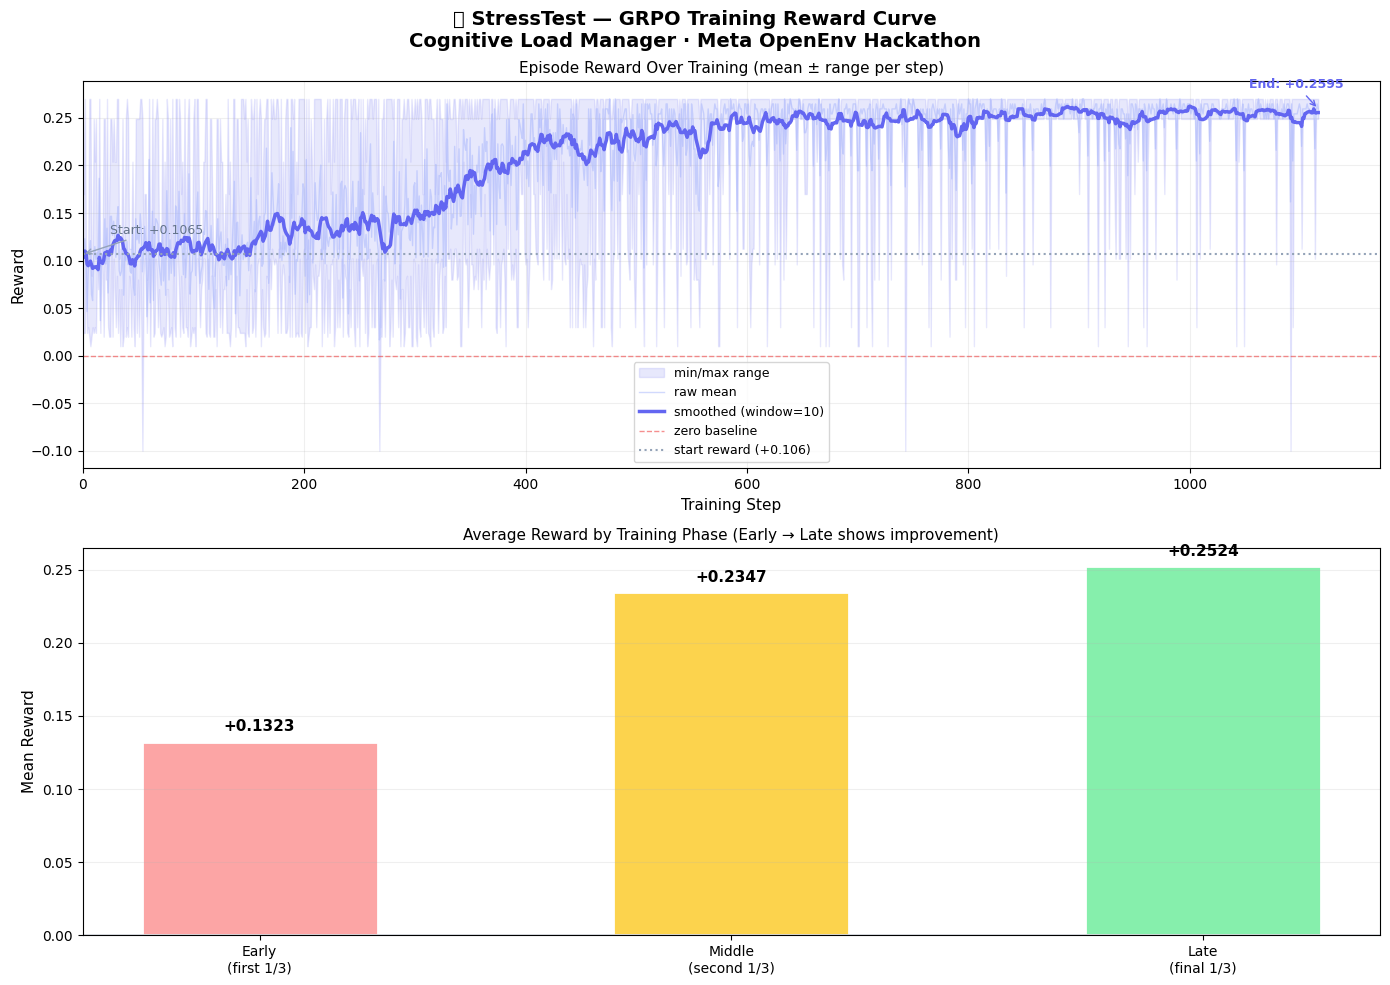


✅ Plot saved to reward_curve.png
   Start reward: +0.1065
   End reward:   +0.2595
   Improvement:  +0.1530


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

with open('/content/reward_curve.json') as f:
    curve = json.load(f)

steps  = [d['step'] for d in curve]
means  = [d['mean'] for d in curve]
maxes  = [d['max']  for d in curve]
mins   = [d['min']  for d in curve]

# Smooth mean (rolling average over 10 steps)
window = 10
smoothed = []
for i in range(len(means)):
    start = max(0, i - window)
    smoothed.append(sum(means[start:i+1]) / (i - start + 1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('🧠 StressTest — GRPO Training Reward Curve\n'
             'Cognitive Load Manager · Meta OpenEnv Hackathon',
             fontsize=14, fontweight='bold')

# ── Top plot: reward curve ──────────────────────────────────────────────
ax1.fill_between(steps, mins, maxes, alpha=0.15, color='#6366f1', label='min/max range')
ax1.plot(steps, means,    color='#a5b4fc', linewidth=1, alpha=0.5, label='raw mean')
ax1.plot(steps, smoothed, color='#6366f1', linewidth=2.5, label=f'smoothed (window={window})')
ax1.axhline(y=0, color='#ef4444', linestyle='--', linewidth=1, alpha=0.6, label='zero baseline')
ax1.axhline(y=means[0] if means else 0, color='#94a3b8', linestyle=':',
            linewidth=1.5, label=f'start reward ({means[0]:+.3f})')

if means:
    ax1.annotate(f'Start: {means[0]:+.4f}', xy=(steps[0], means[0]),
                 xytext=(20, 15), textcoords='offset points',
                 fontsize=9, color='#64748b',
                 arrowprops=dict(arrowstyle='->', color='#94a3b8'))
    ax1.annotate(f'End: {means[-1]:+.4f}', xy=(steps[-1], means[-1]),
                 xytext=(-50, 15), textcoords='offset points',
                 fontsize=9, color='#6366f1', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#6366f1'))

ax1.set_xlabel('Training Step', fontsize=11)
ax1.set_ylabel('Reward', fontsize=11)
ax1.set_title('Episode Reward Over Training (mean ± range per step)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.set_xlim(left=0)

# ── Bottom plot: improvement sections ──────────────────────────────────
n = len(means)
if n >= 3:
    third = n // 3
    phase1 = means[:third]
    phase2 = means[third:2*third]
    phase3 = means[2*third:]
    phases = ['Early\n(first 1/3)', 'Middle\n(second 1/3)', 'Late\n(final 1/3)']
    avgs = [sum(p)/len(p) if p else 0 for p in [phase1, phase2, phase3]]
    colors = ['#fca5a5', '#fcd34d', '#86efac']
    bars = ax2.bar(phases, avgs, color=colors, edgecolor='white', linewidth=2, width=0.5)
    for bar, avg in zip(bars, avgs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{avg:+.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax2.axhline(y=0, color='#64748b', linewidth=1)
    ax2.set_ylabel('Mean Reward', fontsize=11)
    ax2.set_title('Average Reward by Training Phase (Early → Late shows improvement)', fontsize=11)
    ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('/content/reward_curve.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig(os.path.join(PROJECT_DIR, 'reward_curve.png'), dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('\n✅ Plot saved to reward_curve.png')
print(f'   Start reward: {means[0]:+.4f}')
print(f'   End reward:   {means[-1]:+.4f}')
print(f'   Improvement:  {means[-1]-means[0]:+.4f}')

## Cell 13 — Download All Results

In [14]:
from google.colab import files

print('📥 Downloading all results...')

# Download the files judges need to see
for fname in ['reward_curve.json', 'reward_curve_full.json', 'reward_curve.png']:
    fpath = f'/content/{fname}'
    if os.path.exists(fpath):
        files.download(fpath)
        print(f'  ✅ {fname}')
    else:
        print(f'  ❌ {fname} not found')

print('\n📋 What to do with these files:')
print('  reward_curve.json      → copy to your project root (backend serves it at /training-log)')
print('  reward_curve.png       → embed in README.md for judges')
print('  reward_curve_full.json → optional detailed log for blog post')

📥 Downloading all results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ reward_curve.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ reward_curve_full.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ reward_curve.png

📋 What to do with these files:
  reward_curve.json      → copy to your project root (backend serves it at /training-log)
  reward_curve.png       → embed in README.md for judges
  reward_curve_full.json → optional detailed log for blog post
